Dataset loaded with shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Dataset after filtering and feature engineering:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,errorBalanceOrig,errorBalanceDest
2,1,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,0.00,181.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,0.00,21363.0
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,213808.94,182703.5
19,1,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,214605.30,237735.3
24,1,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,300850.89,-2401220.0


Dataset after cleaning and encoding:


,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,type_TRANSFER
2,181.00,181.0,0.0,0.0,0.00,1,0.00,181.0,1
3,181.00,181.0,0.0,21182.0,0.00,1,0.00,21363.0,0
15,229133.94,15325.0,0.0,5083.0,51513.44,0,213808.94,182703.5,0
19,215310.30,705.0,0.0,22425.0,0.00,0,214605.30,237735.3,1
24,311685.89,10835.0,0.0,6267.0,2719172.89,0,300850.89,-2401220.0,1


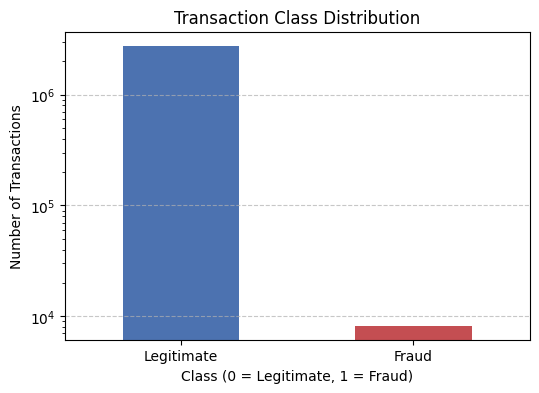

Shape of X_train: (2216327, 8)
Shape of y_train: (2216327,)
Shape of X_test: (554082, 8)
Shape of y_test: (554082,)
Class imbalance ratio (non-fraud / fraud): 336.34
XGBoost model training complete.
--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.94      1.00      0.97      1643

    accuracy                           1.00    554082
   macro avg       0.97      1.00      0.98    554082
weighted avg       1.00      1.00      1.00    554082

ROC-AUC Score: 0.9984266462284972
Model successfully saved as 'Best Model.pkl'


['/content/drive/MyDrive/Fraud/Best Model.pkl']

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import joblib


df = pd.read_csv("/content/drive/MyDrive/Fraud/Datas.csv")
print(f"Dataset loaded with shape: {df.shape}")
display(df.head())

df = pd.read_csv('/content/drive/MyDrive/Fraud/Datas.csv')

# Keep only TRANSFER and CASH_OUT types where fraud occurs
df = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

# Create accounting discrepancy features
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

print("Dataset after filtering and feature engineering:")
display(df.head())

# Drop unique IDs, timestamps, and old rule columns
df = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud', 'step'])

# One-hot encode the transaction type column into numeric format
df = pd.get_dummies(df, columns=['type'], drop_first=True, dtype=int)

print("Dataset after cleaning and encoding:")
display(df.head())

# Plot a simple bar chart of the target variable
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(6, 4))
fraud_counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Transaction Class Distribution')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')
plt.xticks(ticks=[0, 1], labels=['Legitimate', 'Fraud'], rotation=0)
plt.yscale('log') # Log scale helps visualize the massive difference
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

X = df.drop('isFraud', axis=1)
y = df['isFraud']

# Stratified split to preserve the exact fraud ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Calculate the imbalance multiplier so the model prioritizes rare fraud cases
ratio = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Class imbalance ratio (non-fraud / fraud): {ratio:.2f}")

model = XGBClassifier(
    scale_pos_weight=ratio,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Train the model on the training set
model.fit(X_train, y_train)

print("XGBoost model training complete.")

# Predict classes and probabilities on the unseen test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Print out results
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

joblib.dump(model, 'Best Model.pkl')
print("Model successfully saved as 'Best Model.pkl'")
# To load the model later in another session or script:
# loaded_model = joblib.load('fraud_detector_model.pkl')

# This saves the model straight to your Google Drive folder permanently
joblib.dump(model, '/content/drive/MyDrive/Fraud/Best Model.pkl')

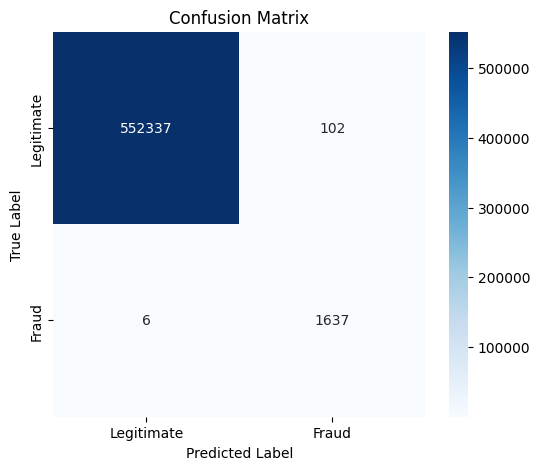

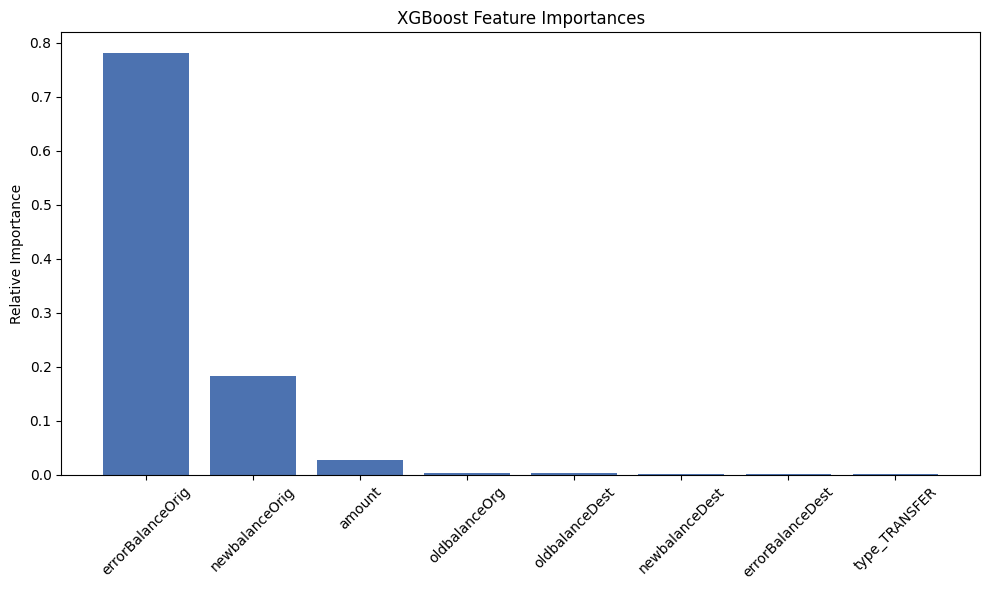

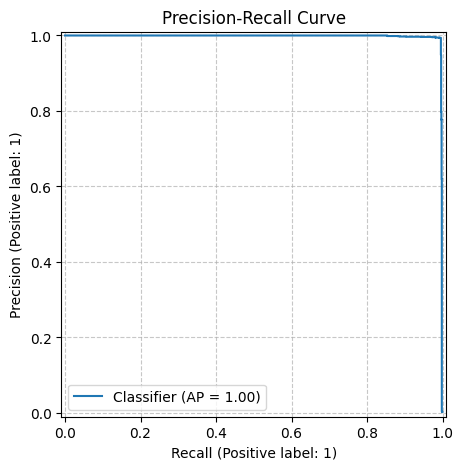

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import PrecisionRecallDisplay, confusion_matrix

# --- Confusion Matrix Plot ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# --- Feature Importance Plot ---
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("XGBoost Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align="center", color="#4C72B0")
plt.xticks(range(X.shape[1]), [feature_names[i] for i in indices], rotation=45)
plt.ylabel("Relative Importance")
plt.tight_layout()
plt.show()

# --- Precision-Recall Curve ---
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=plt.gca())
plt.title("Precision-Recall Curve")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Lower the probability threshold from 0.5 to catch more fraud cases
custom_threshold = 0.3
y_pred_custom = (y_prob >= custom_threshold).astype(int)

print(
    f"--- Classification Report (Custom Threshold = {custom_threshold}) ---"
)
print(classification_report(y_test, y_pred_custom))

--- Classification Report (Custom Threshold = 0.3) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.90      1.00      0.95      1643

    accuracy                           1.00    554082
   macro avg       0.95      1.00      0.97    554082
weighted avg       1.00      1.00      1.00    554082



In [ ]:
import joblib
import pandas as pd

# ==========================================
# 1. LOAD SAVED MODEL & DEFINE THRESHOLD
# ==========================================
# Load the model you saved to your Google Drive
model_path = "/content/drive/MyDrive/Fraud/Best Model.pkl"
model = joblib.load(model_path)

# Set your chosen decision threshold (e.g., 0.30)
OPTIMAL_THRESHOLD = 0.30

# Expected training feature names in exact order
FEATURE_COLUMNS = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "errorBalanceOrig",
    "errorBalanceDest",
    "type_TRANSFER",
]


# ==========================================
# 2. INFERENCE FUNCTION FOR NEW TRANSACTIONS
# ==========================================
def predict_fraud(raw_transaction: dict, threshold: float = OPTIMAL_THRESHOLD):
    """Takes a raw transaction dictionary, engineers features, and predicts fraud risk."""
    # Convert incoming raw dictionary to DataFrame
    data = pd.DataFrame([raw_transaction])

    # Feature Engineering (Same logic as training step)
    data["errorBalanceOrig"] = (
        data["newbalanceOrig"] + data["amount"] - data["oldbalanceOrg"]
    )
    data["errorBalanceDest"] = (
        data["oldbalanceDest"] + data["amount"] - data["newbalanceDest"]
    )

    # One-hot encoding handling for 'type'
    data["type_TRANSFER"] = 1 if data["type"].iloc[0] == "TRANSFER" else 0

    # Ensure correct columns and feature ordering
    data_processed = data[FEATURE_COLUMNS]

    # Predict fraud probability
    fraud_probability = model.predict_proba(data_processed)[0][1]

    # Apply custom threshold decision rule
    is_fraud = bool(fraud_probability >= threshold)

    return {
        "is_fraud": is_fraud,
        "fraud_probability": round(float(fraud_probability), 4),
        "applied_threshold": threshold,
        "status": (
            "FLAGGED AS FRAUD" if is_fraud else "APPROVED (Legitimate)"
        ),
    }


# ==========================================
# 3. TEST WITH MOCK TRANSACTIONS
# ==========================================

# Example 1: Legitimate CASH_OUT transaction
sample_legit = {
    "type": "CASH_OUT",
    "amount": 500.00,
    "oldbalanceOrg": 1000.00,
    "newbalanceOrig": 500.00,
    "oldbalanceDest": 2000.00,
    "newbalanceDest": 2500.00,
}

# Example 2: Suspicious TRANSFER with zeroed-out balances
sample_suspicious = {
    "type": "TRANSFER",
    "amount": 950000.00,
    "oldbalanceOrg": 950000.00,
    "newbalanceOrig": 0.00,
    "oldbalanceDest": 0.00,
    "newbalanceDest": 0.00,
}

print("--- Testing Sample 1 (Legit) ---")
print(predict_fraud(sample_legit))

print("\n--- Testing Sample 2 (Suspicious) ---")
print(predict_fraud(sample_suspicious))

--- Testing Sample 1 (Legit) ---
{'is_fraud': False, 'fraud_probability': 0.0001, 'applied_threshold': 0.3, 'status': 'APPROVED (Legitimate)'}

--- Testing Sample 2 (Suspicious) ---
{'is_fraud': True, 'fraud_probability': 1.0, 'applied_threshold': 0.3, 'status': 'FLAGGED AS FRAUD'}
